In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [32]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

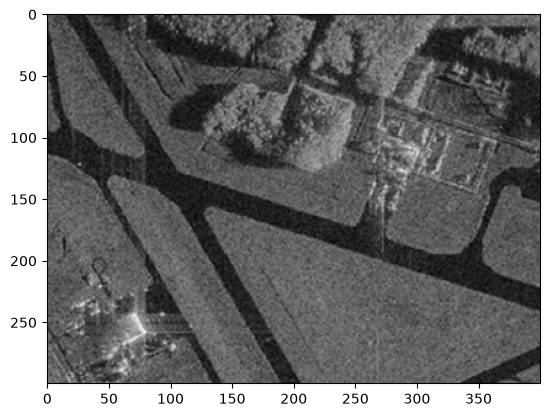

In [33]:
plt.imshow(image_gray, cmap="gray")

In [34]:
#1

In [35]:
import math
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False

In [36]:
def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
        
    return mask*255

In [37]:
seed_point = (250,250)
mask = region_growing(image_gray,seed_point,homo_average,3, 25)

35
85
135
185
233
277
333
383
430
479
532
583
632
681
736
619
559
587
606
616
604
599
589
575
550
561
533
522
506
492
470
453
442
420
405
389
367
345
330
307
290
272
258
247
235
219
210
193
153
82
79
70
66
64
59
55
46
41
32
23
53
0


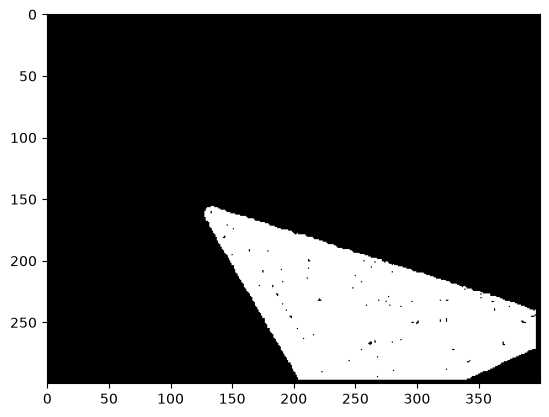

In [38]:
plt.imshow(mask, cmap="gray")

In [72]:
#2

In [83]:
# texture + brightness + closeness
def homo_texture(image, mask, point, T):
    i, j = point
    
    neighborhood = mask[i - 1 : i + 2, j - 1 : j + 2]
    if neighborhood.sum() == 0:
        return False
        
    region_pixels = image[mask > 0]
    if region_pixels.size == 0:
        return False
        
    region_mean = np.mean(region_pixels.astype(float))
    
    window = image[i - 1 : i + 2, j - 1 : j + 2].astype(float)
    local_std = np.std(window)
    
    brightness_diff = abs(int(image[point]) - region_mean)
    
    if brightness_diff <= T and local_std <= T:
        return True
        
    return False

In [74]:
mask_hybrid = region_growing(image_gray,seed_point,homo_texture,3, 25)

8
16
24
32
40
47
56
64
72
80
88
96
102
110
120
124
131
143
150
160
168
175
184
191
198
207
215
219
230
236
247
256
263
269
280
287
294
301
310
318
326
344
343
346
351
350
254
255
249
242
245
240
236
236
231
227
225
224
216
217
211
211
206
203
202
198
194
193
186
207
185
177
172
167
167
167
162
159
154
154
152
147
143
140
139
135
134
135
134
131
127
126
123
123
120
117
116
113
109
107
106
101
101
96
96
94
94
94
92
88
86
84
80
79
77
75
71
69
64
59
58
55
49
48
47
46
46
45
45
44
43
42
41
40
38
37
37
36
37
35
34
33
31
31
30
31
35
0


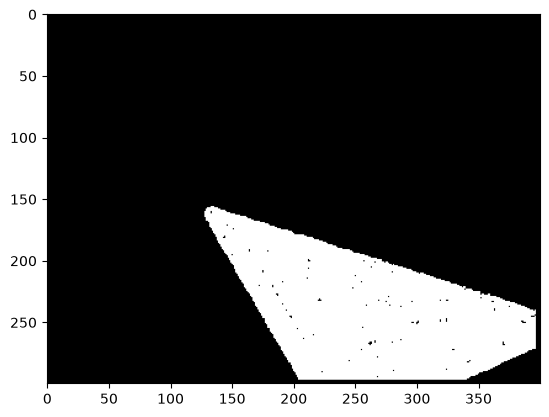

In [75]:
plt.imshow(mask_hybrid, cmap="gray")

In [78]:
from skimage.metrics import structural_similarity, mean_squared_error

mse = mean_squared_error(mask_texture, mask)

(ssim, diff) = structural_similarity(mask_texture,  mask, full=True)

print(mse, ssim)

7216.149375 0.8083581059068544


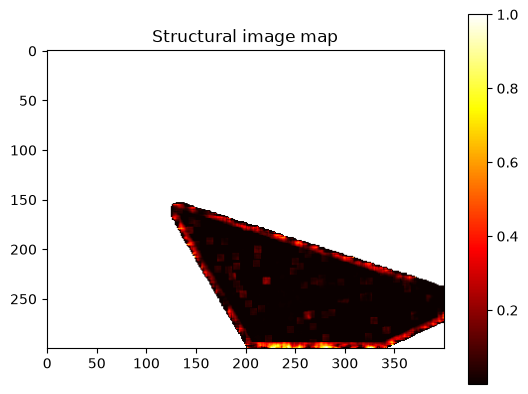

In [82]:
plt.imshow(diff, cmap='hot')
plt.title("Structural image map")
plt.colorbar()
plt.show()

In [120]:
#3

In [121]:
image = cv2.imread('palm_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
blurred = cv2.GaussianBlur(image_gray, (25, 25), 0)

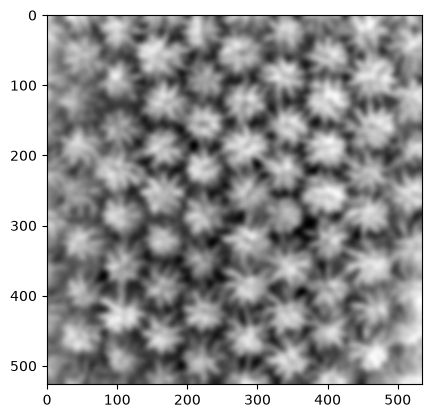

In [122]:
plt.imshow(blurred, cmap="gray")

In [123]:
ret, thresh = cv2.threshold(blurred,0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

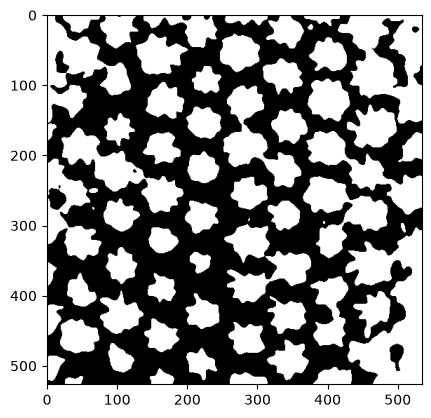

In [124]:
plt.imshow(thresh, cmap="gray")

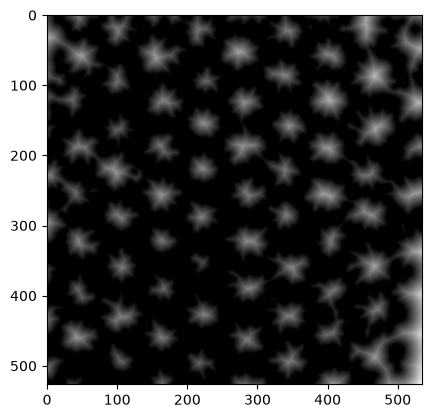

In [125]:
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
plt.imshow(dist, cmap="gray")

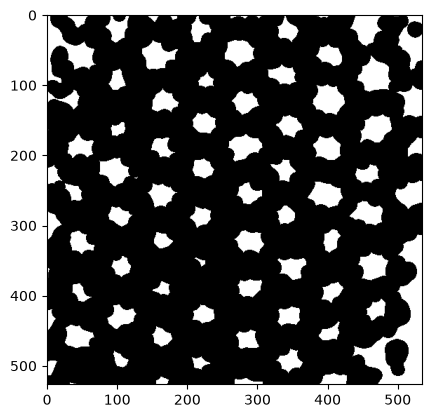

In [126]:
ret, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, cv2.THRESH_BINARY) 
plt.imshow(sure_fg, cmap="gray")

In [127]:
sure_fg = sure_fg.astype(np.uint8)

In [128]:
ret, markers = cv2.connectedComponents(sure_fg) 

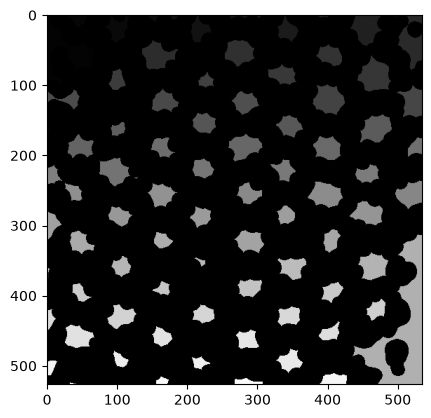

In [129]:
plt.imshow(markers, cmap="gray")

In [130]:
print("Nearly ~", len(np.unique(markers)), "palms")

Nearly ~ 85 palms


In [118]:
markers = cv2.watershed(image, markers)

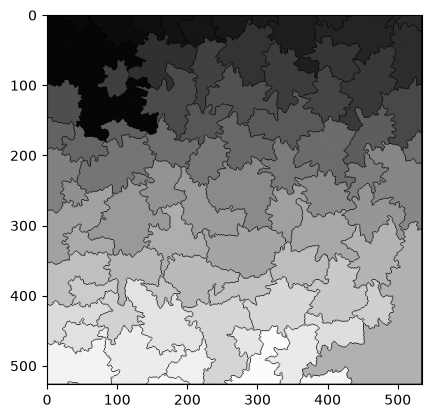

In [119]:
plt.imshow(markers, cmap="gray")